# Phase 1 of APP

In [ ]:
pip install networkx matplotlib pandas pypdf scipy

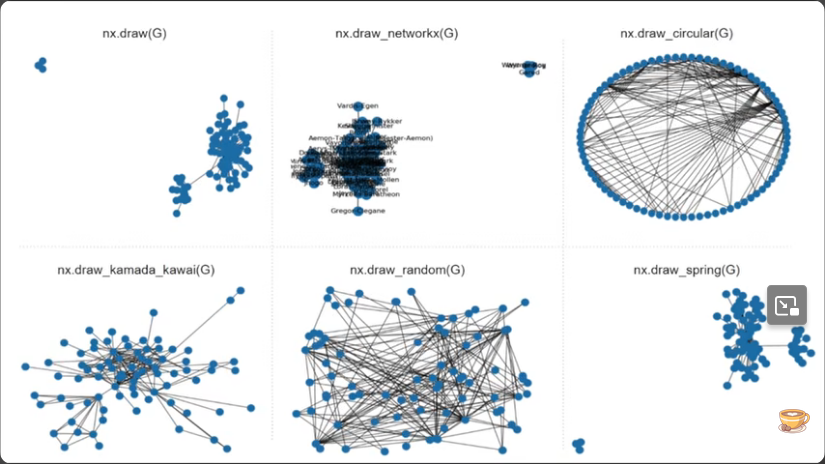

In [84]:
import networkx as nx

edges = [
    ("Bob", "Alice", 12), 
    ("Kevin", "Alice", 5), 
    ("Bob", "Kevin", 7), 
    ("Alice", "John", 25), 
    ("Bob", "John", 42), 
    ("John", "Kevin", 15), 
    ("Charlize", "Alice", 21), 
    ("John", "Charlize", 8),

    ("Sarah", "Alice", 18),
    ("Sarah", "Bob", 9),
    ("Sarah", "Kevin", 14),
    ("Sarah", "John", 20),
    
    ("Daniel", "Alice", 30),
    ("Daniel", "Kevin", 16),
    ("Daniel", "Charlize", 22),

    ("Mike", "John", 27),
    ("Mike", "Kevin", 10),
    ("Mike", "Sarah", 13),

    ("Emily", "Bob", 17),
    ("Emily", "Charlize", 19),
    ("Emily", "Sarah", 11),
    
    ("Sophia", "Alice", 26),
    ("Sophia", "Daniel", 14),
    ("Sophia", "Emily", 8),

    ("Liam", "Mike", 12),
    ("Liam", "John", 23),
    ("Liam", "Sarah", 9),

    ("Olivia", "Kevin", 18),
    ("Olivia", "Emily", 7),
    ("Olivia", "Sophia", 20),
]


G = nx.Graph()
G.add_weighted_edges_from(edges, weight='weight')

## Visualizations

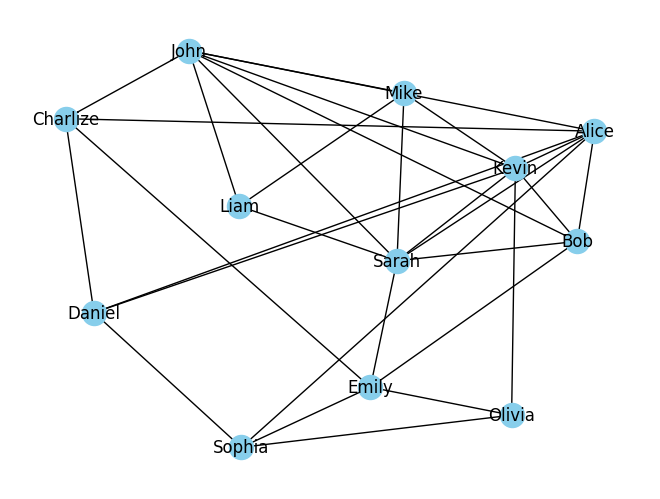

In [60]:
#Matplotlib version
import matplotlib.pyplot as plt

pos = nx.kamada_kawai_layout(G)
nx.draw(G, with_labels=True, node_color='skyblue', edge_cmap=plt.cm.Blues, pos=pos)

plt.show()

In [ ]:
#Pyvis version
from pyvis.network import Network
from IPython.display import IFrame

net = Network(notebook=False, width='1000px', height='700px', bgcolor='#222222', font_color='white', cdn_resources='remote')

net.barnes_hut(gravity=-1200, spring_length=80, damping=0.09)

# Add nodes
for node in G.nodes():
    net.add_node(node, size=G.degree[node]*2)

# Add edges with visual weight
for edge in G.edges(data=True):
    source, target, data = edge
    weight = data['weight']
    # Scale the weight for visual effect (adjust divisor as needed)
    net.add_edge(source, target, value=weight/3, title=f"Weight: {weight}")

net.write_html("view.html")
IFrame('view.html', width='1000px', height='700px')

## Measures

In [65]:
# Degree Centrality - number of connections
degree_cent = nx.degree_centrality(G)
print("Degree Centrality:")
for node, cent in sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {node}: {cent:.3f}")
    
# Betweenness Centrality - how often node appears on shortest paths
betweenness_cent = nx.betweenness_centrality(G, weight='weight')
print("\nBetweenness Centrality:")
for node, cent in sorted(betweenness_cent.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {node}: {cent:.3f}")
    
# Closeness Centrality - average distance to all other nodes
closeness_cent = nx.closeness_centrality(G, distance='weight')
print("\nCloseness Centrality:")
for node, cent in sorted(closeness_cent.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {node}: {cent:.3f}")

# Eigenvector Centrality - connections to well-connected nodes
eigenvector_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
print("\nEigenvector Centrality:")
for node, cent in sorted(eigenvector_cent.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {node}: {cent:.3f}")

Degree Centrality:
  Alice: 0.636
  Kevin: 0.636
  John: 0.636
  Sarah: 0.636
  Bob: 0.455

Betweenness Centrality:
  Kevin: 0.297
  Emily: 0.218
  Sarah: 0.124
  John: 0.091
  Charlize: 0.055

Closeness Centrality:
  Kevin: 0.060
  Sarah: 0.058
  Bob: 0.054
  Emily: 0.053
  Alice: 0.051

Eigenvector Centrality:
  John: 0.499
  Alice: 0.428
  Bob: 0.350
  Sarah: 0.322
  Kevin: 0.258


In [67]:
# Clustering Coefficient - how connected neighbors are
clustering = nx.clustering(G)
print("\nClustering Coefficient:")
for node, coef in sorted(clustering.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {node}: {coef:.3f}")

# Average Clustering
avg_clustering = nx.average_clustering(G)
print(f"\nAverage Clustering: {avg_clustering:.3f}")


Clustering Coefficient:
  Liam: 1.000
  Mike: 0.833
  Bob: 0.700
  John: 0.524
  Sarah: 0.524

Average Clustering: 0.515


In [ ]:
# Average Shortest Path Length
if nx.is_connected(G):
    avg_path_length = nx.average_shortest_path_length(G, weight='weight')
    print(f"\nAverage Shortest Path Length: {avg_path_length:.3f}")
    
# Diameter (longest shortest path)
if nx.is_connected(G):
    diameter = nx.diameter(G, weight='weight')
    print(f"Network Diameter: {diameter:.3f}")
    
# Shortest path between two specific nodes
p1 = "Liam"
p2 = "Daniel"
path = nx.shortest_path(G, p1, p2, weight='weight')
path_length = nx.shortest_path_length(G, p1, p2, weight='weight')
print(f"\nShortest path {p1} → {p2}: {' → '.join(path)}")
print(f"Path length: {path_length:.2f}")


Average Shortest Path Length: 21.182
Network Diameter: 38.000

Shortest path Liam→ Daniel: Liam → Mike → Kevin → Daniel
Path length: 38.00


## Community Visuals

In [ ]:
from networkx.algorithms import community
from pyvis.network import Network

# Detect communities
communities = community.louvain_communities(G, weight='weight')
print(f"Found {len(communities)} communities")

# Map nodes to community IDs
community_map = {}
for i, comm in enumerate(communities):
    print(f"Community {i}: {sorted(comm)}")
    for node in comm:
        community_map[node] = i

# Create visualization
net = Network(notebook=False, width='1000px', height='700px', 
              bgcolor='#222222', font_color='white', cdn_resources='remote')

# Add nodes with community coloring
for node in G.nodes():
    net.add_node(node, 
                 label=node,
                 size=G.degree[node]*3,
                 group=community_map[node],  # Pyvis auto-colors by group
                 title=f"Community {community_map[node]}")

# Add edges
for u, v, data in G.edges(data=True):
    weight = data['weight']
    net.add_edge(u, v, value=weight/3, title=f"Weight: {weight}")

net.barnes_hut(gravity=-1000, spring_length=80, damping=0.09)
net.write_html('com_view.html')

Found 3 communities
Community 0: ['Bob', 'John', 'Liam', 'Mike', 'Sarah']
Community 1: ['Alice', 'Charlize', 'Daniel', 'Emily', 'Sophia']
Community 2: ['Kevin', 'Olivia']


In [96]:
# Find communities using Louvain method
from networkx.algorithms import community
communities = community.louvain_communities(G, weight='weight')
print(f"\nNumber of communities: {len(communities)}")
for i, comm in enumerate(communities, 1):
    print(f"  Community {i}: {comm}")


Number of communities: 3
  Community 1: {'Emily', 'Alice', 'Sophia', 'Charlize', 'Daniel'}
  Community 2: {'Bob', 'John', 'Mike', 'Sarah', 'Liam'}
  Community 3: {'Kevin', 'Olivia'}
